# Finding Outliers in PCA Plot

This notebook loads the PCA results and identifies outliers based on distance from the center of the PCA space.

In [1]:
import numpy as np
import json
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import os

In [2]:
# Specify path to PCA output
os.chdir(Path.cwd().parent)
pca_output_root = Path("subsetWithValidatedCalls/pca_output") # CHANGE THIS TO PATH TO PCA OUTPUT

print(f"Files found: at {pca_output_root}:")
for f in pca_output_root.glob("*"):
    print(f"-{f.name}")

Files found: at subsetWithValidatedCalls/pca_output:
-pca_results.npz
-window_index.npz
-pca_plot.png
-pca_meta.json


In [3]:
# Load PCA data
pca_data = np.load(pca_output_root / "pca_results.npz", allow_pickle=True)
X_pca = pca_data["X_pca"]
evr = pca_data["evr"] # explained variance ratio

print(f"X_pca shape: {X_pca.shape}") # should have shape (n_samples, n_components)


X_pca shape: (5824, 20)


In [4]:
# Load window metadata
window_data = np.load(pca_output_root / "window_index.npz", allow_pickle=True)
files = window_data["files"]
start_frames = window_data["start_frames"]
start_secs = window_data["start_secs"]

print(f"{len(files)} windows")
print(f"for example: {files[:5]}")

5824 windows
for example: ['6230.220914214000.npz' '6230.220914214000.npz' '6230.220914214000.npz'
 '6230.220914214000.npz' '6230.220914214000.npz']


In [5]:
# Load metadata
with open(pca_output_root / "pca_meta.json") as f:
    meta = json.load(f)

print(f"PCA analysis metadata:")
print(f"  Created: {meta['created']}")
print(f"  Total windows: {meta['n_windows']}")
print(f"  n Components: {meta['n_components']}")
print(f"  Files in root: {len(meta['files'])}")


PCA analysis metadata:
  Created: 2026-03-24T16:57:29.701079
  Total windows: 5824
  n Components: 20
  Files in root: 112


In [36]:
# Calculate distance from center in PCA space
# Alternatively try using Mahalanobis afstand

# Euclidean distance from mean
mean_pca = X_pca.mean(axis=0)
distances_euclidean = np.sqrt(np.sum((X_pca - mean_pca) ** 2, axis=1))
print(X_pca.shape)
print(mean_pca.shape)
print(distances_euclidean.shape)

# Mahalanobis distance from mean
cov_pca = np.cov(X_pca, rowvar=False) # rowvar to correct for samples in rows
inv_cov = np.linalg.inv(cov_pca)


distances_mahal = [np.sqrt((X_pca[i] - mean_pca).T @ inv_cov @ (X_pca[i] - mean_pca)) for i in range(X_pca.shape[0])]
distances_mahal = np.array(distances_mahal)


print(f"Euclidean distance stats:")
print(f"  Mean: {distances_euclidean.mean():.3f}, Std: {distances_euclidean.std():.3f}")
print(f"  Min: {distances_euclidean.min():.3f}, Max: {distances_euclidean.max():.3f}")
print(f"\nMahalanobis distance stats:")
print(f"  Mean: {distances_mahal.mean():.3f}, Std: {distances_mahal.std():.3f}")
print(f"  Min: {distances_mahal.min():.3f}, Max: {distances_mahal.max():.3f}")

(5824, 20)
(20,)
(5824,)
Euclidean distance stats:
  Mean: 20.065, Std: 11.583
  Min: 2.591, Max: 180.625

Mahalanobis distance stats:
  Mean: 4.218, Std: 1.485
  Min: 1.915, Max: 20.968


In [ ]:
# Define outliers and make mask
distances = distances_mahal
print(distances[:10]) # print first 10 distances for reference
threshold = distances.mean() + 3 * distances.std() # outlier defined as more than 3 std dev from mean
outlier_mask = distances > threshold
outlier_indices = np.asarray(outlier_mask).nonzero()[0] #apply mask to get indices of outliers
#outlier_indices = np.where(outlier_mask)[0]

print(f"Threshold: {threshold:.3f}")
print(f"Number of outliers: {len(outlier_indices)} out of {len(distances)} windows")

[2.88043716 3.78931505 3.56769429 2.81064334 4.34002469 3.12258834
 3.79532844 3.28546945 4.97120004 3.74667017]
Threshold: 13.673
Number of outliers: 24 out of 5824 windows


In [24]:
# Create detailed table of outliers with source information
outlier_info = []

for idx in outlier_indices:
    outlier_info.append({
        "Index": idx,
        "File": files[idx],
        "Start Frame": int(start_frames[idx]),
        "Start Time (s)": float(start_secs[idx]),
        "Distance": distances[idx],
        "PC1": X_pca[idx, 0],
        "PC2": X_pca[idx, 1] if X_pca.shape[1] > 1 else 0,
    })

outlier_df = pd.DataFrame(outlier_info)
outlier_df = outlier_df.sort_values(["File", "Start Time (s)"], ascending=[True, True])

print(outlier_df.to_string())

    Index                   File  Start Frame  Start Time (s)   Distance         PC1        PC2
0     556  6230.220915010000.npz        22500           180.0  16.935446  -50.518524 -12.106728
1     564  6230.220915010000.npz        27500           220.0  15.377512  -52.955853  -3.235646
2    1444  6230.220915064000.npz        25000           200.0  18.432241  -48.560925  15.309606
3    1737  6230.220917074000.npz        13125           105.0  14.157282  -37.130169  -1.685884
4    1753  6230.220917074000.npz        23125           185.0  13.869132  -25.263767   1.023158
5    2397  6230.220917120000.npz         3125            25.0  19.333599  -34.046200  -9.908672
6    2405  6230.220917120000.npz         8125            65.0  17.616020  -47.523785  -9.606452
7    2421  6230.220917120000.npz        18125           145.0  19.092441  -52.312679 -13.969863
8    2436  6230.220917120000.npz        27500           220.0  19.134805  -25.071796 -14.836134
9    2438  6230.220917120000.npz        

In [25]:
# Group outliers by source file
outliers_by_file_grouped = outlier_df.groupby("File").size().sort_values(ascending=False)
outliers_by_file = outlier_df.sort_values("File", ascending=False)
print(outliers_by_file_grouped.to_string())
print(outliers_by_file.to_string())

File
6230.221003000000.npz    7
6230.220917120000.npz    6
6230.220915010000.npz    2
6230.220917074000.npz    2
6230.220915064000.npz    1
6230.220917130000.npz    1
6230.220917140000.npz    1
6230.220917142000.npz    1
6230.220917164000.npz    1
6230.221002184000.npz    1
6230.221003010000.npz    1
    Index                   File  Start Frame  Start Time (s)   Distance         PC1        PC2
23   5093  6230.221003010000.npz        30625           245.0  14.691584   21.275423  -2.321139
22   4931  6230.221003000000.npz        26875           215.0  15.458819  -14.301017  15.537658
21   4930  6230.221003000000.npz        26250           210.0  15.396433   -5.972268  -1.028170
20   4922  6230.221003000000.npz        21250           170.0  20.280177   -8.901802  -7.291399
19   4916  6230.221003000000.npz        17500           140.0  19.147795  -11.033823  -7.621058
18   4913  6230.221003000000.npz        15625           125.0  14.382551    1.613889  -7.732824
17   4909  6230.2210030000

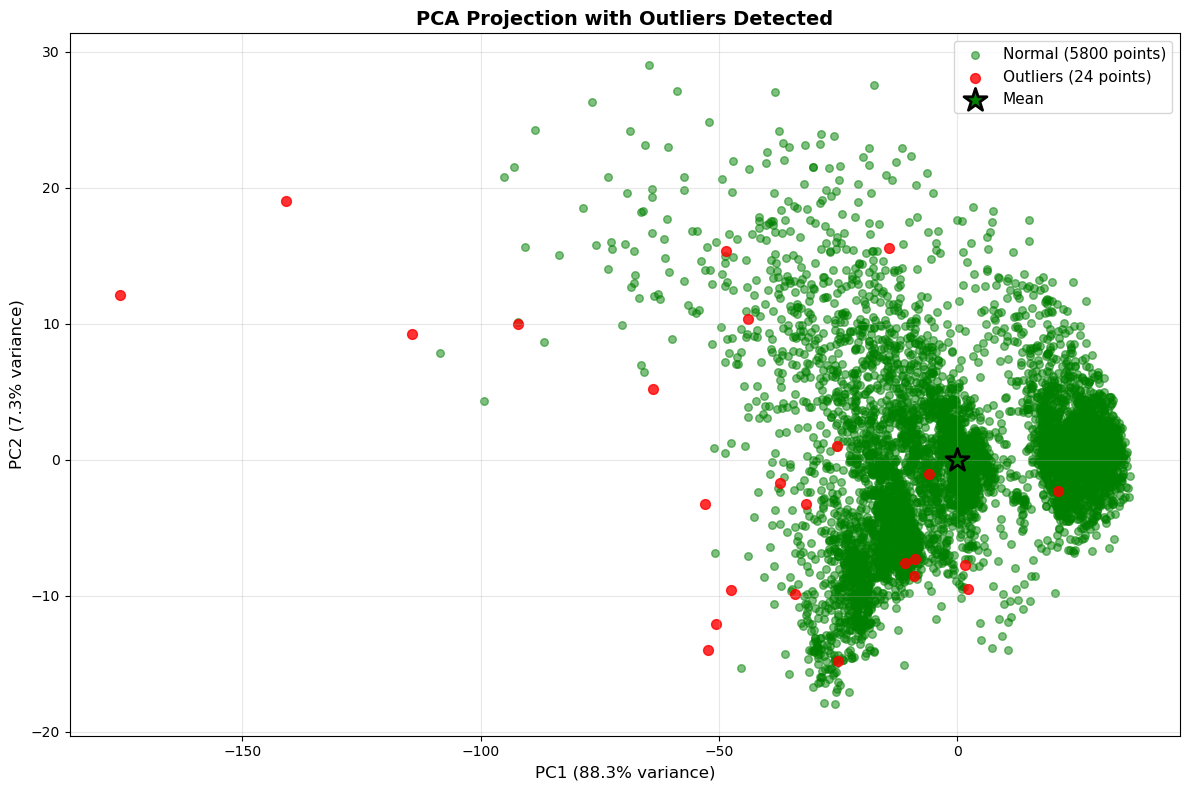

In [ ]:
# Visualize PCA plot with outliers highlighted
assert X_pca.shape[1] >= 2, "minimum 2 PCA components for plotting"
fig, ax = plt.subplots(figsize=(12, 8))

# Plot normal points
normal_mask = ~outlier_mask
normal_x = X_pca[normal_mask, 0]
normal_y = X_pca[normal_mask, 1]
ax.scatter(normal_x, normal_y, 
            c='green', alpha=0.5, s=30, label=f'Normal ({normal_mask.sum()} points)')

# Plot outliers
outlier_x = X_pca[outlier_mask, 0]
outlier_y = X_pca[outlier_mask, 1]
ax.scatter(outlier_x, outlier_y, 
            c='red', alpha=0.8, s=50, label=f'Outliers ({outlier_mask.sum()} points)')

# Plot center
ax.scatter(mean_pca[0], mean_pca[1], c='green', s=300, 
            marker='*', label='Mean', zorder=5, edgecolors='black', linewidths=2)

ax.set_xlabel(f'PC1 ({evr[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({evr[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('PCA Projection with Outliers marked', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
#out_plot = pca_output_root / "outliers_pca_plot.png"
#plt.savefig(out_plot, dpi=150, bbox_inches='tight')
plt.show()

#print(f"\nPlot saved to: {out_plot}")


In [ ]:
# Save outlier summary to CSV
csv_path = pca_output_root / "outliers_summary.csv"
outlier_df.to_csv(csv_path, index=False)
print(f"Outlier summary saved to: {csv_path}")
print(f"Total outliers: {len(outlier_df)}")

Outlier summary saved to: analysis/pca_output/testrun/outliers_summary.csv

Total outliers extracted: 2
